📊 Análisis Económico: Argentina vs México (2000–2026)

01. Carga del conjunto de datos
Objetivo

En esta primera etapa se importan las librerías necesarias y se carga el archivo JSON que contiene la información histórica de ambos países.

Después, en una celda de código:

In [1]:
# Carga del dataset
import pandas as pd
from google.colab import files #drive

archivos = files.upload()

df = pd.read_json("dataset.json")



# Conectar al drive
# drive.mount("/content/drive", force_remount=True)

# Ruta del archivo
# ruta = "/content/drive/MyDrive/Data Analytics/02_Dataset/dataset.json"


Saving dataset.json to dataset.json


02. Exploración inicial del dataset
Objetivo

Verificar que el conjunto de datos se haya cargado correctamente e identificar el número de registros y columnas disponibles.

Código:

In [ ]:
# ==========================================================
# MÓDULO 2. EXPLORACIÓN INICIAL DEL DATASET
# ==========================================================

# Mostrar las primeras filas
df.head()

# Obtener el número de registros y columnas
filas, columnas = df.shape

print(f"Número de registros: {filas}")
print(f"Número de columnas: {columnas}")

# Mostrar información general del DataFrame
df.info()

# CONCLUSIÓN
# El dataset contiene 27 registros y 15 columnas. La mayoría de las variables
#no presentan valores faltantes y los tipos de datos son adecuados para iniciar
#el análisis exploratorio.


📊 3. Información general del dataset.

Objetivo: Conocer la estructura del conjunto de datos para identificar:

*   Número de registros
*   Cantidad de columnas
*   Tipos de valores
*   Valores nulos
*   Posibles valores faltantes

# Código:


In [ ]:
# Numero de registros y cantidad de columnas

filas, columnas = df.shape

print(f"Número de registros: {filas}")
print(f"Número de columnas: {columnas}")

Número de registros: 27
Número de columnas: 15


In [ ]:
# Tipos de valores

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   anio                            27 non-null     int64  
 1   presidente_argentina            27 non-null     object 
 2   presidente_mexico               27 non-null     object 
 3   partido_argentina               27 non-null     object 
 4   partido_mexico                  27 non-null     object 
 5   orientacion_politica_argentina  27 non-null     object 
 6   orientacion_politica_mexico     27 non-null     object 
 7   ars_por_usd                     27 non-null     float64
 8   mxn_por_usd                     27 non-null     float64
 9   ars_mxn                         27 non-null     float64
 10  inflacion_argentina             26 non-null     float64
 11  inflacion_mexico                26 non-null     float64
 12  evento_principal                27 non

In [ ]:
# Contar valores nulos por columnas
df.isnull().sum()

# Calcular el porcentaje de valores nulos
df.isnull().sum() / len(df) * 100

# Mostrar únicamente las filas con valores nulos
df[df.isnull().any(axis=1)]

,anio,presidente_argentina,presidente_mexico,partido_argentina,partido_mexico,orientacion_politica_argentina,orientacion_politica_mexico,ars_por_usd,mxn_por_usd,ars_mxn,inflacion_argentina,inflacion_mexico,evento_principal,categoria_evento,fuente
26,2026,Javier Milei,Claudia Sheinbaum,La Libertad Avanza,Morena,Derecha (libertario),Izquierda,1410.0,18.9,74.6032,NaN,NaN,Continuidad del esquema de flotación cambiaria...,Estabilidad,BCRA; INDEC; Banxico; INEGI; FMI (dato parcial...


📊4. Estadísticas descriptivas Objetivo

Obtener un resumen estadístico de las variables numéricas para comprender su comportamiento antes de comenzar con las visualizaciones.

In [ ]:
# Obtener estadísticas descriptivas de las variables numéricas
df.describe().round()

,anio,ars_por_usd,mxn_por_usd,ars_mxn,inflacion_argentina,inflacion_mexico
count,27.0,27.0,27.0,27.0,26.0,26.0
mean,2013.0,160.0,15.0,9.0,34.0,5.0
std,8.0,381.0,4.0,20.0,46.0,2.0
min,2000.0,1.0,9.0,0.0,-2.0,2.0
25%,2006.0,3.0,11.0,0.0,9.0,4.0
50%,2013.0,5.0,13.0,0.0,18.0,4.0
75%,2020.0,59.0,19.0,3.0,41.0,5.0
max,2026.0,1410.0,21.0,75.0,211.0,9.0


📊 Módulo 5. Análisis Univariado
Objetivo

Analizar cada variable de manera individual para comprender su distribución, comportamiento y posibles valores atípicos mediante estadísticas y visualizaciones.

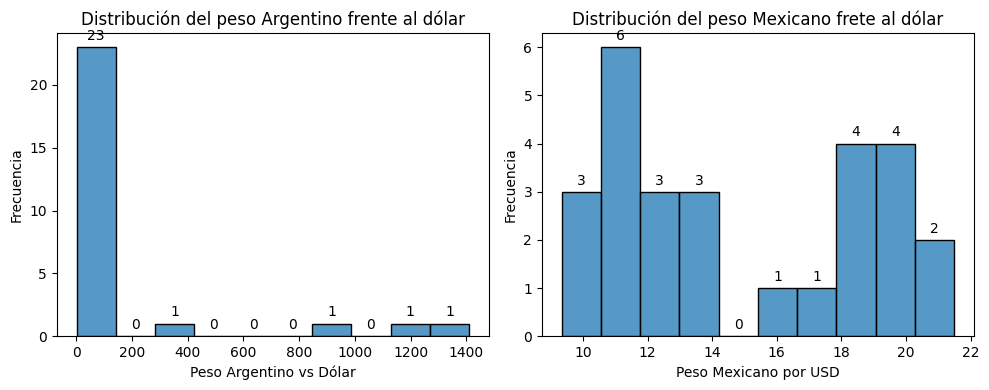

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

# Recargar matplotlib
importlib.reload(plt)

# Crear una figura con dos gráficos
fig, ax = plt.subplots(1, 2, figsize = (10,4))

# -------------------------
# Histograma Peso Argentino
# -------------------------

sns.histplot(df["ars_por_usd"],bins=10, ax=ax[0])

ax[0].set_title("Distribución del peso Argentino frente al dólar")
ax[0].set_xlabel("Peso Argentino vs Dólar")
ax[0].set_ylabel("Frecuencia")

# Agregar etiqueta a las barras
for contenedor in ax[0].containers:
  ax[0].bar_label(contenedor, fmt="%.0f", padding=3)

  # -------------------------
# Histograma Peso Mexicano
# ---------------------------

sns.histplot(df["mxn_por_usd"], bins=10, ax=ax[1])

ax[1].set_title("Distribución del peso Mexicano frete al dólar")
ax[1].set_xlabel("Peso Mexicano por USD")
ax[1].set_ylabel("Frecuencia")

# Agregar etiquetas a las barras
for contenedor in ax[1].containers:
  ax[1].bar_label(contenedor, fmt="%.0f", padding=3)

 # Ajustar espacios
plt.tight_layout()

 # Mostrar gráficos
plt.show()

Comparación entre ambas distribuciones:

La comparación de ambos histogramas permite identificar una diferencia muy clara
entre las dos economías.

Mietras el peso argentino presenta una distribución altamente asimétrica debido
al fuerte incremento del tipo de cambio en los ultimos años, el peso mexicano
mantiene una distribución mucho más estable y homogenea. Esta evidencia visual
confirma los resultados obtenidos previamente mediante las estadísticas
descriptivas, donde argentina mostró una mayor dispersión y desviación estándar
que México.

📊 Módulo 5.3 Gráficos de Líneas

Objetivo

Analizar el tipo de cambio del peso argentino y del peso mexicano frente al dólar usd durante el periodo 2020-2026, con el fin de identificar tendencias,
cambios relevantes y diferenciasa en el comportamiento de ambas monedas a lo
largo del tiempo

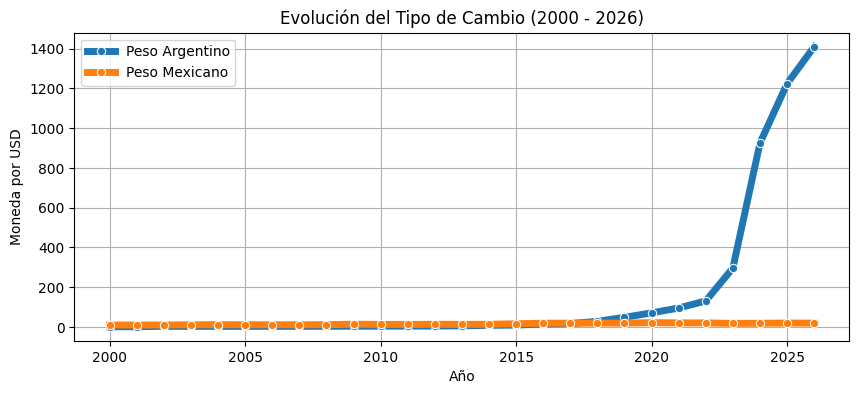

In [ ]:
# ==========================================================
# MÓDULO 5. ANÁLISIS UNIVARIADO
# 5.3 GRÁFICO DE LÍNEAS
# EVOLUCIÓN DEL TIPO DE CAMBIO
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Tamaño del gráfico
plt.figure(figsize=(10,4))

# Peso Argentino
sns.lineplot(data=df, x="anio",y="ars_por_usd",marker="o",linewidth=5,label="Peso Argentino"
)

# Peso Mexicano
sns.lineplot(data=df, x="anio",y="mxn_por_usd",marker="o",linewidth=5,label="Peso Mexicano"
)

plt.title("Evolución del Tipo de Cambio (2000 - 2026)")

plt.xlabel("Año")

plt.ylabel("Moneda por USD")

plt.grid(True)

plt.legend()

plt.show()

Comparación entre ambas monedas


*   El peso Argentino muestra una depreciación acelerada en los últimos año.
*   El peso Mexicano mantiene un comportamiento relativamente estable.


*   La distancia entre ambas curvas aumenta conforme avanza el tiempo, evidenciando que el ritmo de depreciación de ambas monedas ha sido diferente.

Esta comparación permite visualizar claramente cómo dos economías latinoamericanas pueden presentar comportamientos cambiarios muy distintos durante el mismo periodo


Insight

El análisis temporal evidencia que el peso argentino experimentó una depreciación mucho más acelerada que el peso mexicano entre los años 2000-2026.
Mientras que Argentino presenta una tendencia creciente con cambios pronunciados en los años recientes, México mantiene un comportamiento relativamente estable, con fluctuaciones moderadas. Estas diferencias reflejan niveles distintos de estabilidad cambiaria durante el periodo analizado.










📊 Módulo 5.3 Gráfico de barras

Objetivo

Analizar la frecuencia de las categorías de eventos registrados en el dataset, durante el periodo 2000-2026, con el propósito de identificar cuáles fueron los tipos de acontecimientos más recurrentes.


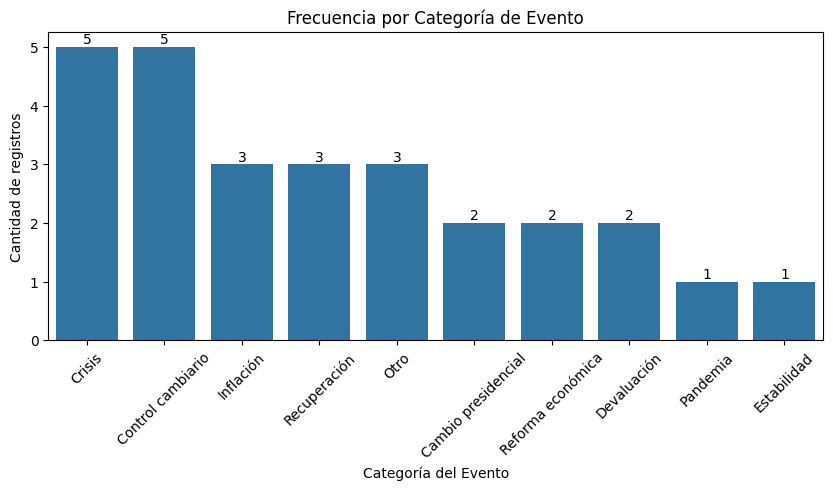

In [ ]:
# ==========================================================
# MÓDULO 5. ANÁLISIS UNIVARIADO
# 5.4 GRÁFICO DE BARRAS
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))

sns.countplot(
    data=df,
    x="categoria_evento",
    order=df["categoria_evento"].value_counts().index
)

for contenedor in plt.gca().containers:
  plt.bar_label(contenedor)

plt.title("Frecuencia por Categoría de Evento")

plt.xlabel("Categoría del Evento")

plt.ylabel("Cantidad de registros")

plt.xticks(rotation=45)

plt.show()

📊 Módulo 6. Análisis Bivariado

Objetivo:
Calcular la correlación entre las variables numéricas del dataset para identificar si existe una relación líneal entre ellas y medir qué tan fuerte es dicha relación.

In [ ]:
# ==========================================================
# MÓDULO 6
# 6.2 MATRIZ DE CORRELACIÓN
# ==========================================================

variables_numericas = df.select_dtypes(include=["number"])

matriz_correlacion = variables_numericas.corr().round(2)

matriz_correlacion

,anio,ars_por_usd,mxn_por_usd,ars_mxn,inflacion_argentina,inflacion_mexico
anio,1.00,0.62,0.93,0.62,0.65,-0.10
ars_por_usd,0.62,1.00,0.44,1.00,0.40,-0.09
mxn_por_usd,0.93,0.44,1.00,0.43,0.55,-0.03
ars_mxn,0.62,1.00,0.43,1.00,0.42,-0.09
inflacion_argentina,0.65,0.40,0.55,0.42,1.00,0.08
inflacion_mexico,-0.10,-0.09,-0.03,-0.09,0.08,1.00


Insight del Analista

La matriz de correlación muestra que el comportamiento del peso argentino presenta una relación positiva con el paso del tiempo y con la inflación, lo que refleja una tendencia de depreciación acompañada por un incremento sostenido de los niveles inflacionarios. En contraste, el peso mexicano muestra una evolución mucho más estable, ya que su tipo de cambio no presenta una realción significativa con la inflación durante el periodo analizado. Además, la correlación perfecta entre ARS/USD y ARS/MXN confirma que ambas variables evolucionan prácticamente de forma conjunta.

📊 Módulo 6.3 Heatmap (Mapa de calor)

Objetivo:
Visualizar la matriz de correlación mediante un mapa de calor para identificar rápidamente las relaciones fuerte, moderadas y débiles entre las variables


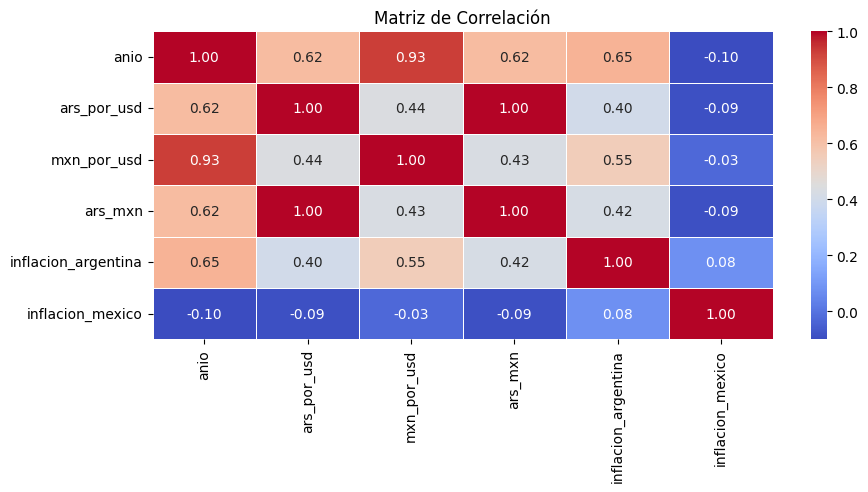

In [ ]:
# ==========================================================
# MÓDULO 6
# 6.3 HEATMAP
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

# Annot = True: Hace que aparezcan números dentro de cada cuadro.
# Sin esto solo veriamos colores
# cmap="coolwarm" define la paleta de colores.
# Azul: Correlaciones negativas
# Blanco: Correlaciones cercanas a cero
# Rojo: Correlaciones positivas.

plt.title("Matriz de Correlación")
plt.show()

Insight del Analista

El Heatmap permite identificar visualmente las relaciones entre las variables del conjunto de datos. En este análisis destacan las correlaciones positivas entre el año y los tipos de cambio, así como la relación prácticamente perfecta entre ARS/USD y ARS/MXN. Por otro lado, las variables relacionadas con la inflación en México presentan correlaciones cercanas a cero, lo que sugiere una baja asociación lineal con las demás variables.

⏭️ Próxima sección
6.4 Scatter Plot (Gráfico de Dispersión)

Objetivo:
Visualizar la relación entre dos variables numéricas mediante un gráfico de dispersión para identificar tendencias, agrupaciones y posibles valores atípicos.



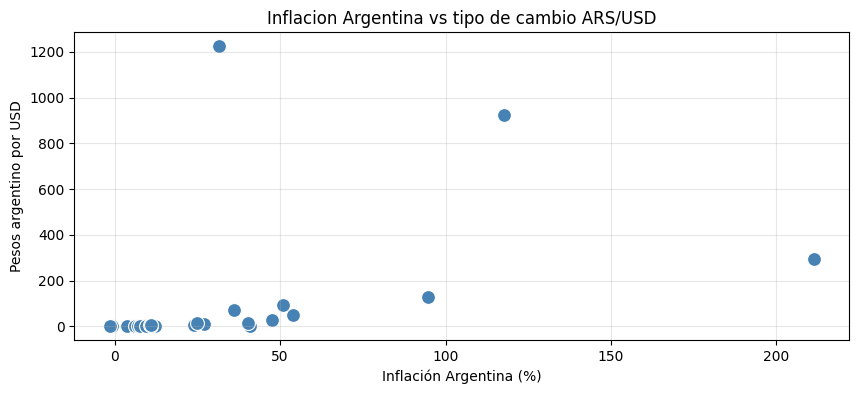

In [ ]:
# ==========================================================
# MÓDULO 6
# 6.4 SCATTER PLOT
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))

sns.scatterplot(
    data=df, x="inflacion_argentina",
    y="ars_por_usd",
    s=100,
    color="steelblue")

plt.title("Inflacion Argentina vs tipo de cambio ARS/USD")
plt.xlabel("Inflación Argentina (%)")
plt.ylabel("Pesos argentino por USD")

plt.grid(alpha=0.3)
plt.show()


# Observaciones:
# sns.scatterplot(): Es la función que crea el gráfico de dispersión.
# data=df : Indica que utilizaremos el DataFrame principal.
# s=100 : Controla el tamaño de los puntos
# plt.grid(alpha = 0.3): Agrega una cuadricula ligera para facilitar la lectura

Insight del Analista

El gráfico de dispersión permite observar visualmente la relación entre la inflación argentina y el tipo de cambio frente al dólar. Se espera una tendencia ascendente moderada, consistente con la correlación obtenida previamente (0.40). Aunque la relación no es perfecta, el gráfico ayuda a identificar patrones y posibles valores atípicos que no son evidentes únicamente con la matriz de correlación.

MÓDULO 7. ANÁLISIS COMPARATIVO

Objetivo:
Compara la evolución de las principales variables económicas de Argentina y México entre los años 2000 y 2026, identificando diferencias, tendencias y patrones relevante.

7.1 COMPARACIÓN DEL TIPO DE CAMBIO
Objetivo:

Comparar la evolución del peso Argentino y del peso Mexicano frente al dólar durante el periodo 2000 - 2026



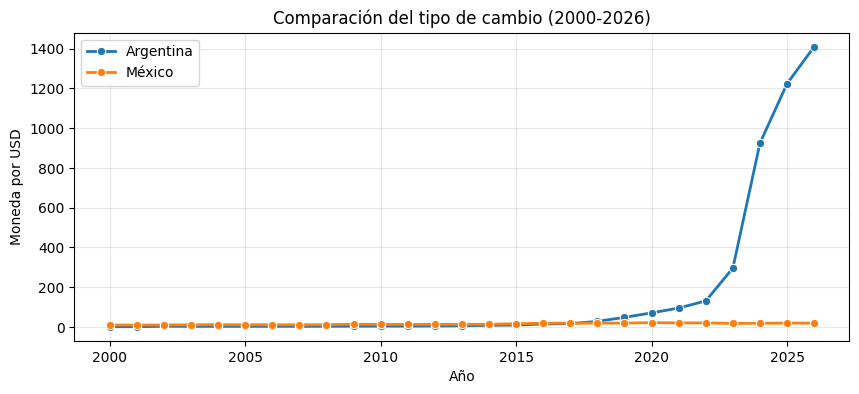

In [ ]:
# ==========================================================
# MÓDULO 7
# 7.1 COMPARACIÓN DEL TIPO DE CAMBIO
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

# Recargamos importlib
importlib.reload(plt)

# Tamaño de la figura
plt.figure(figsize=(10, 4))

# Gráfico

sns.lineplot(
    data=df,
    x="anio",
    y="ars_por_usd",
    marker="o",
    linewidth=2,
    label="Argentina")

sns.lineplot(
    data=df,
    x="anio",
    y="mxn_por_usd",
    marker="o",
    linewidth=2,
    label="México"
)

plt.title("Comparación del tipo de cambio (2000-2026)")
plt.xlabel("Año")
plt.ylabel("Moneda por USD")

plt.grid(alpha=0.3)
plt.legend() # Muestra la leyenda con los nombres de cada pais
plt.show()

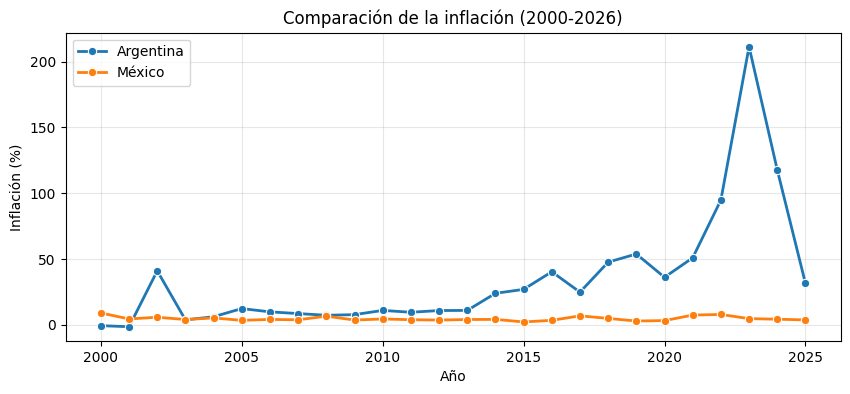

In [ ]:
# ==========================================================
# MÓDULO 7
# 7.2 COMPARACIÓN DE LA INFLACIÓN
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
import importlib

importlib.reload(plt)

plt.figure(figsize=(10,4))

# Valores para la variable: inflacion_argentina
ax[0]=sns.lineplot(
    data=df,
    x="anio",
    y="inflacion_argentina",
    marker="o",
    linewidth=2,
    label="Argentina")

# Etique de datos
for contenedor in ax[0].containers:
  ax[0].lineplot(contenedor)

# Valores para la variable: inflación_mexico
ax[1]=sns.lineplot(
    data=df,
    x="anio",
    y="inflacion_mexico",
    marker="o",
    linewidth=2,
    label="México"
)

# Etique de datos
for contenedor in ax[1].containers:
  ax[1].lineplot(contenedor)

plt.title("Comparación de la inflación (2000-2026)")
plt.xlabel("Año")
plt.ylabel("Inflación (%)")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

Insight del Analista
La comparación de la inflación evidencia comportamientos económicos diferentes entre ambos países. Mientras Argentina presenta una tendencia creciente y una mayor volatilidad, México mantiene niveles de inflación más estables durante gran parte del periodo analizado. Esta diferencia ayuda a explicar, al menos en parte, la mayor depreciación observada en la moneda argentina.

MÓDULO 7. ANÁLISIS COMPARATIVO
7.3 COMPARACIÓN DE EVENTOS ECONÓMICOS

Objetivo:
Analizar la distribución de los eventos económicos registrados en el dataset para identificar cuáles fueron los acontecimientos más frecuentes durante el periodo 2000-2026 y comprender el contexto en el que evolucionan ambas economías.



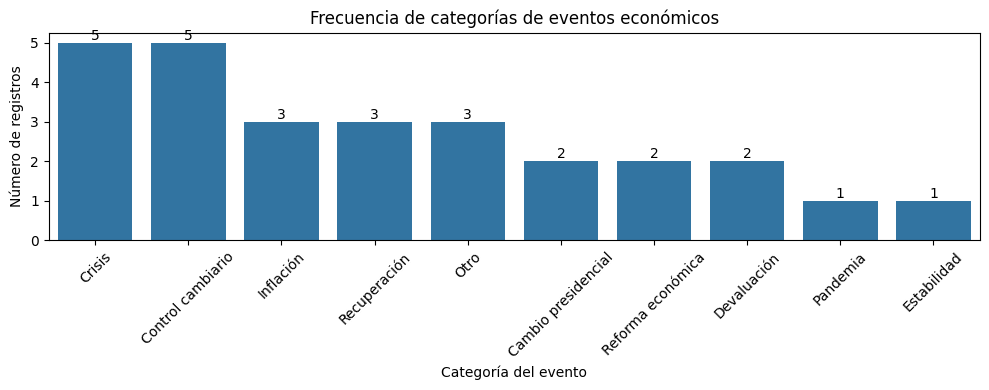

In [ ]:
# ==========================================================
# MÓDULO 7
# 7.3 COMPARACIÓN DE EVENTOS ECONÓMICOS
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
import importlib

importlib.reload(plt)

plt.figure(figsize=(10,4))

ax = sns.countplot(
    data=df,
    x="categoria_evento",
    order=df["categoria_evento"].value_counts().index)  # Value_counts: Ordena
    # las barras desde la categoría más frecuente hasta la menos frecuente.

# Agrega etiquetas sobre las barras:
for contenedor in ax.containers:
  ax.bar_label(contenedor)


plt.title("Frecuencia de categorías de eventos económicos")
plt.xlabel("Categoría del evento")
plt.ylabel("Número de registros")


plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

7.4 COMPARACIÓN POR PERIODOS PRESIDENCIALES
Objetivo:

Analizar cómo se distribuyen los registros del dataset según los presidentes de Argentina y México durante el periodo 2000-2026, con el proposito de contextualizar los cambios económicos observados.

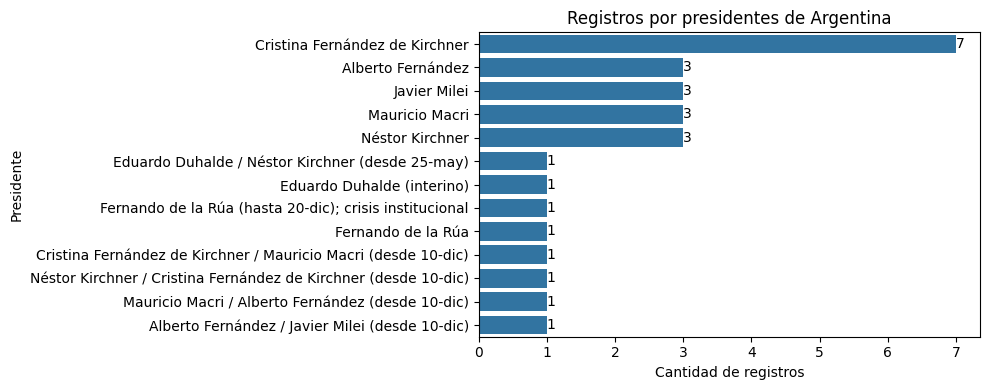

In [ ]:
# ==========================================================
# MÓDULO 7
# 7.4 PRESIDENTES DE ARGENTINA
# ==============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import importlib

importlib.reload(plt)


plt.figure(figsize=(10,4))

ax = sns.countplot(
    data=df,
    y="presidente_argentina",
    order=df["presidente_argentina"].value_counts().index)

# Agregar etiquetas
for contenedor in ax.containers:
  ax.bar_label(contenedor)

plt.title("Registros por presidentes de Argentina")
plt.xlabel("Cantidad de registros")
plt.ylabel("Presidente")

plt.tight_layout()
plt.show()

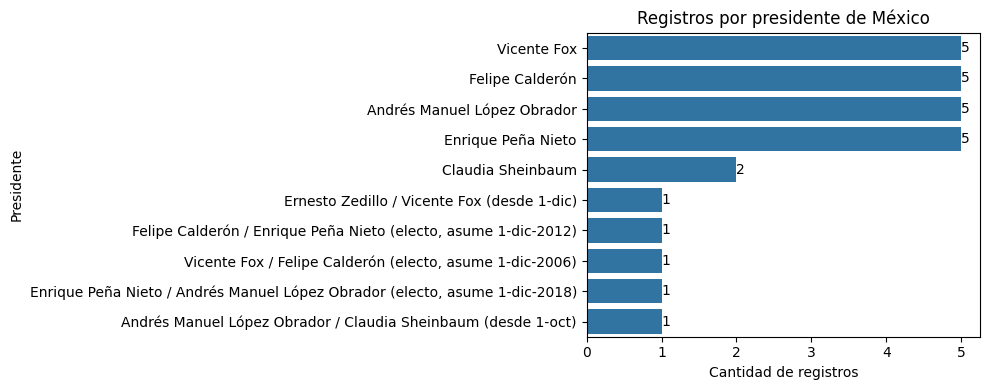

In [ ]:
# ==========================================================
# MÓDULO 7
# 7.4 PRESIDENTES DE MÉXICO
# ==============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import importlib

importlib.reload(plt)

plt.figure(figsize=(10,4))

ax = sns.countplot(
    data=df,
    y="presidente_mexico",
    order=df["presidente_mexico"].value_counts().index)

for contenedor in ax.containers:
  ax.bar_label(contenedor)

plt.title("Registros por presidente de México")
plt.xlabel("Cantidad de registros")
plt.ylabel("Presidente")

plt.tight_layout()
plt.show()

MÓDULO 8. HALLAZGOS E INSIGHTS

Objetvio:
Identificar los principales hallazgos obtenidos durante el análisis exploratorio y transformarlos en conclusiones claras que apoyen la toma de decisiones.


Hallazgo 1. Evolución del tipo de cambio.

Durante el periodo comprendido entre 2000 y 2026, el peso argentino presentó una depreciación mucho más acelerada que el peso mexicano frente al dólar estadounidense.

Evidencia. Este comportamiento fue observado mediante:

*   Gráfico de líneas.
*   Estadísticas descriptivas.
*   Comparación entre ambos páises.

Interpretación
Mientras Argentina experimentó incrementos muy pronunciados en el tipo de cambio, México mostró una evolución considerablemente más estable.

La diferencia entre ambas economías se hizo más evidente durante los últimos años del periodo analizado.

Insight del Analista:
El análisis muestra una diferencia clara en la estabilidad cambiara entre ambos países. Aunque las dos monedas experimentaron incrementos en su tipo de cambio frente al dólar, la depreciación observada en Argentina fue considerablemente mayor que la registrada en México.





Módulo 9. Construcción del DASHBOARD.

Objetivo.
Diseñar un dashboard ejecutivo que resuma los principales indicadores y hallazgos del análisis comparativo entre Argentina y México durante el periodo 2000-2026.

9.1 Definición de KPIs
Objetivo:
Construir los indicadores principales que aparecerán en la parte superior del dashboard para resumir la información más importante del análisis.


In [ ]:
# ==========================================================
# MÓDULO 9
# 9.1 DEFINICIÓN DE KPIs
# ==========================================================

# Periodo analizado
periodo = f"{df['anio'].min()} - {df['anio'].max()}"

# Tipo de cambio máximo de Argentina
max_ars = df["ars_por_usd"].max()

# Tipo de cambio máximo de México
max_mxn = df["mxn_por_usd"].max()

# Total de registros
total_registros = len(df)

# Mostrar KPIs
print("========== KPIs DEL DASHBOARD ==========")

print(f"📅 Periodo Analizado: {periodo}")

print(f"🇦🇷 Máximo ARS/USD: {max_ars:,.2f}")    # ",":separador de miles

print(f"🇲🇽 Máximo MXN/USD: {max_mxn:.2f}")     # "2.f":Dos decimales.

print(f"📊 Total de Registros: {total_registros}")

========== KPIS DEL DASHBOARD ==========
📅 Periodo Analizado: 2000 - 2026
🇦🇷 Máximo ARS/USD: 1,410.00
🇲🇽 Máximo MXN/USD: 21.49
📊 Total de Registros: 27


9.2 CREACIÓN DEL LIENZO (SUBPLOTS)
Objetivo

Crear la estructura del dashboard utilizando matplotlib, donde posteriormente colocaremos cada una de las gráficas.

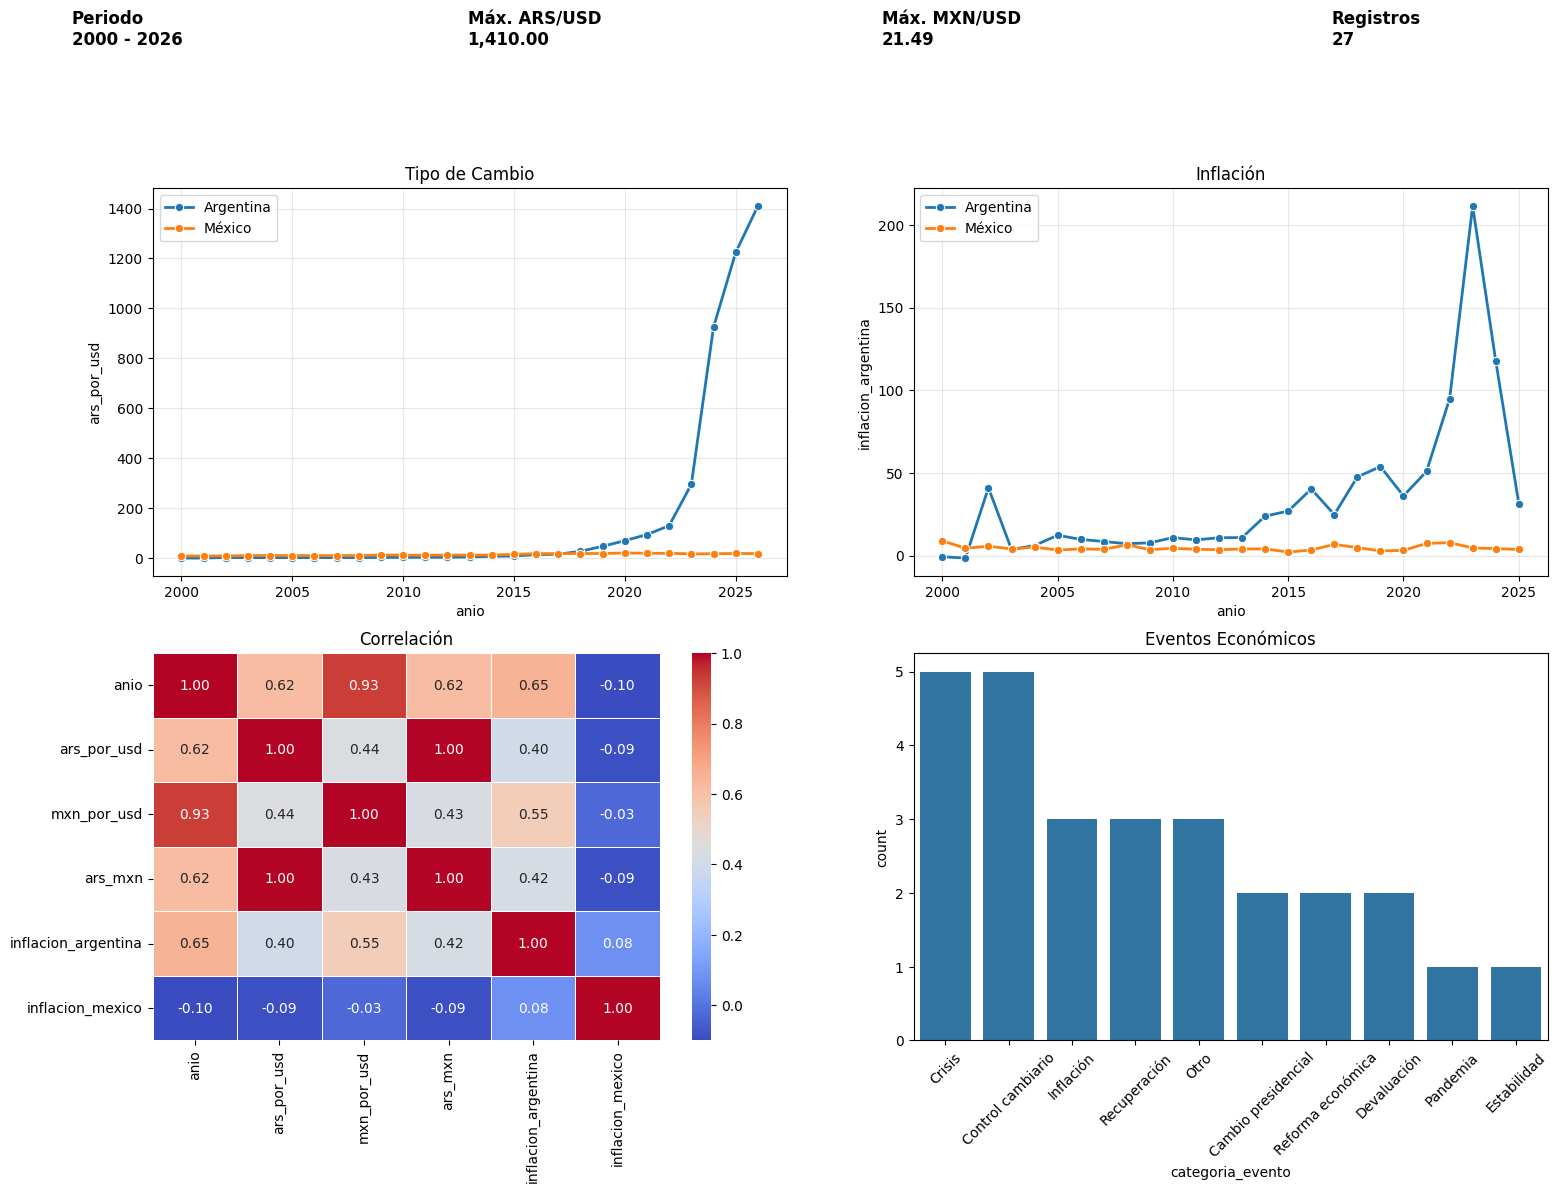

In [ ]:
# ==========================================================
# MÓDULO 9
# 9.5 DASHBOARD EJECUTIVO FINAL
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# KPIs
# ==========================

periodo = f"{df['anio'].min()} - {df['anio'].max()}"
max_ars = df["ars_por_usd"].max()
max_mxn = df["mxn_por_usd"].max()
total_registros = len(df)

# ==========================
# Dashboard
# ==========================

fig, axes = plt.subplots(2, 2, figsize=(18,12))

# Espacio para los KPIs
plt.subplots_adjust(top=0.82)

# ----------------------------------------------------------
# KPI 1
# ----------------------------------------------------------

fig.text(
    0.08,
    0.94,
    f"Periodo\n{periodo}",
    fontsize=12,
    fontweight="bold"
)

# ----------------------------------------------------------
# KPI 2
# ----------------------------------------------------------

fig.text(
    0.30,
    0.94,
    f"Máx. ARS/USD\n{max_ars:,.2f}",
    fontsize=12,
    fontweight="bold"
)

# ----------------------------------------------------------
# KPI 3
# ----------------------------------------------------------

fig.text(
    0.53,
    0.94,
    f"Máx. MXN/USD\n{max_mxn:.2f}",
    fontsize=12,
    fontweight="bold"
)

# ----------------------------------------------------------
# KPI 4
# ----------------------------------------------------------

fig.text(
    0.78,
    0.94,
    f"Registros\n{total_registros}",
    fontsize=12,
    fontweight="bold"
)

# ==========================================================
# 1. Tipo de Cambio
# ==========================================================

sns.lineplot(
    data=df,
    x="anio",
    y="ars_por_usd",
    marker="o",
    linewidth=2,
    label="Argentina",
    ax=axes[0,0]
)

sns.lineplot(
    data=df,
    x="anio",
    y="mxn_por_usd",
    marker="o",
    linewidth=2,
    label="México",
    ax=axes[0,0]
)

axes[0,0].set_title("Tipo de Cambio")
axes[0,0].grid(alpha=0.3)

# ==========================================================
# 2. Inflación
# ==========================================================

sns.lineplot(
    data=df,
    x="anio",
    y="inflacion_argentina",
    marker="o",
    linewidth=2,
    label="Argentina",
    ax=axes[0,1]
)

sns.lineplot(
    data=df,
    x="anio",
    y="inflacion_mexico",
    marker="o",
    linewidth=2,
    label="México",
    ax=axes[0,1]
)

axes[0,1].set_title("Inflación")
axes[0,1].grid(alpha=0.3)

# ==========================================================
# 3. Heatmap
# ==========================================================

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    ax=axes[1,0]
)

axes[1,0].set_title("Correlación")

# ==========================================================
# 4. Eventos
# ==========================================================

sns.countplot(
    data=df,
    x="categoria_evento",
    order=df["categoria_evento"].value_counts().index,
    ax=axes[1,1]
)

axes[1,1].set_title("Eventos Económicos")
axes[1,1].tick_params(axis="x", rotation=45)

